# 20. Symmetric Positive Definite Matrices and Cholesky

**Part 3: Direct Methods for Linear Systems**

## Learning objectives

By the end of this lesson you will be able to:

1. Define **positive definite** and list the equivalent characterisations.
2. Derive the **Cholesky factorization** $A = LL^T$ directly, with no linear system to solve.
3. Explain why Cholesky **needs no pivoting**, and why its growth factor is exactly 1.
4. Show that Cholesky costs $n^3/3$, **half of LU**, and say where the saving comes from.
5. Use a **failed Cholesky as the test** for positive definiteness, and explain why the
   alternatives are worse.
6. Measure **Sylvester's determinant criterion failing** on a comfortably definite matrix.
7. Derive the **LDL$^T$** variant, which avoids square roots and extends to indefinite
   matrices.
8. Use the signs of $D$ to read off the **inertia** without computing an eigenvalue.

## Prerequisites

Lesson 17 (LU, triangular solves). Lesson 18 (pivoting and the growth factor). Lesson 19
(conditioning). Lesson 16 for the inner product view.

---

## 1. Positive definite matrices

> **Definition 20.1.** A symmetric $A \in \mathbb{R}^{n\times n}$ is **positive definite** when
> $$\mathbf{x}^TA\mathbf{x} > 0 \quad\text{for every }\mathbf{x} \ne \mathbf{0}.$$

Several conditions are equivalent to it, and they are worth having in one place because they
are not equally useful numerically.

| Characterisation | Cost to check | Verdict |
|---|---|---|
| $\mathbf{x}^TA\mathbf{x} > 0$ for all $\mathbf{x} \ne 0$ | infinitely many $\mathbf{x}$ | the definition, not a test |
| all eigenvalues positive | $O(n^3)$, large constant | correct, wasteful |
| all leading minor determinants positive (Sylvester) | $O(n^4)$ naively | **numerically hopeless**, section 5 |
| $A = LL^T$ exists with $\ell_{ii} > 0$ | $n^3/3$ | **the right test** |

The last one is the point of this lesson: the factorization and the test are the same
computation.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import cholesky as ch, lu, linalg as la, linsys as ls, pivoting as pv

rng20 = np.random.default_rng(20)

print("the definition, sampled: x^T A x for many random x\n")
print(f"{'matrix':>26} {'min x^T A x':>14} {'max x^T A x':>14} {'positive definite?':>20}")
print("-" * 78)
DIM = 6                                   # one place to change the example size
examples = [
    (f"SPD, random {DIM}x{DIM}", ch.random_spd(DIM, rng=rng20)),
    (f"identity {DIM}x{DIM}", np.eye(DIM)),
    ("indefinite diag(1,-2,3)", np.diag([1.0, -2.0, 3.0])),
    (f"negative definite {DIM}x{DIM}", -np.eye(DIM)),
    (f"singular, rank 1", np.ones((DIM, DIM))),
]
for name, M in examples:
    size = M.shape[0]
    vals = [float(v @ M @ v) for v in
            (rng20.standard_normal(size) for _ in range(4000))]
    print(f"{name:>26} {min(vals):>14.4f} {max(vals):>14.4f} "
          f"{str(ch.is_positive_definite(M)):>20}")

print()
print("row 5 is the interesting one: x^T A x is never NEGATIVE for the all-ones")
print("matrix, but it is zero for any x summing to zero. that is positive")
print("SEMI-definite, and Cholesky correctly refuses it.")

the definition, sampled: x^T A x for many random x

                    matrix    min x^T A x    max x^T A x   positive definite?
------------------------------------------------------------------------------
           SPD, random 6x6         1.5210       477.6687                 True
              identity 6x6         0.0741        25.3519                 True
   indefinite diag(1,-2,3)       -23.0554        43.2375                False
     negative definite 6x6       -26.7205        -0.2368                False
          singular, rank 1         0.0000        82.8743                False

row 5 is the interesting one: x^T A x is never NEGATIVE for the all-ones
matrix, but it is zero for any x summing to zero. that is positive
SEMI-definite, and Cholesky correctly refuses it.


## 2. Deriving Cholesky

Write $A = LL^T$ with $L$ lower triangular, and compare entries. Entry $(i,j)$ of the product
is

$$a_{ij} = \sum_{k} \ell_{ik}\ell_{jk} = \sum_{k \le \min(i,j)} \ell_{ik}\ell_{jk},$$

since $L$ is lower triangular. Take $i = j$ first:

$$a_{jj} = \sum_{k<j}\ell_{jk}^2 + \ell_{jj}^2
\implies \boxed{\ell_{jj} = \sqrt{a_{jj} - \sum_{k<j}\ell_{jk}^2}}$$

and then $i > j$:

$$a_{ij} = \sum_{k<j}\ell_{ik}\ell_{jk} + \ell_{ij}\ell_{jj}
\implies \boxed{\ell_{ij} = \frac{a_{ij} - \sum_{k<j}\ell_{ik}\ell_{jk}}{\ell_{jj}}}.$$

**Every quantity on the right is already known when it is needed.** Work down column by column
and each unknown is read straight off. There is no system to solve: the factorization is a
direct computation.

In [3]:
A = np.array([[  4.0,  12.0, -16.0],
              [ 12.0,  37.0, -43.0],
              [-16.0, -43.0,  98.0]])
L = ch.cholesky(A)

print("A =\n", A, "\n")
print("L =\n", L, "\n")
print("read the derivation off the numbers:")
print(f"   L[0,0] = sqrt(A[0,0]) = sqrt({A[0,0]:.0f}) = {L[0,0]:.0f}")
print(f"   L[1,0] = A[1,0]/L[0,0] = {A[1,0]:.0f}/{L[0,0]:.0f} = {L[1,0]:.0f}")
print(f"   L[1,1] = sqrt(A[1,1] - L[1,0]^2) = sqrt({A[1,1]:.0f} - {L[1,0]**2:.0f}) "
      f"= {L[1,1]:.0f}")
print(f"\n||A - L L^T|| = {np.abs(L @ L.T - A).max():.2e}")
print(f"agrees with numpy.linalg.cholesky to {np.abs(L - np.linalg.cholesky(A)).max():.2e}")
np.testing.assert_allclose(L @ L.T, A, atol=1e-12)
np.testing.assert_allclose(L, np.linalg.cholesky(A), atol=1e-12)

A =
 [[  4.  12. -16.]
 [ 12.  37. -43.]
 [-16. -43.  98.]] 

L =
 [[ 2.  0.  0.]
 [ 6.  1.  0.]
 [-8.  5.  3.]] 

read the derivation off the numbers:
   L[0,0] = sqrt(A[0,0]) = sqrt(4) = 2
   L[1,0] = A[1,0]/L[0,0] = 12/2 = 6
   L[1,1] = sqrt(A[1,1] - L[1,0]^2) = sqrt(37 - 36) = 1

||A - L L^T|| = 0.00e+00
agrees with numpy.linalg.cholesky to 0.00e+00


### From scratch, at any size

In [4]:
def cholesky_from_scratch(A):
    """A = L L^T, written out column by column, for a symmetric positive definite A.

    Reads every dimension from A. Raises when the quantity under the square root is not
    positive, which is the algorithm reporting that A is not positive definite rather than
    failing at it.
    """
    A = np.atleast_2d(np.asarray(A, dtype=float))
    if A.shape[0] != A.shape[1]:
        raise ValueError(f"need a square matrix, got {A.shape}")
    n = A.shape[0]
    L = np.zeros((n, n))
    for j in range(n):
        pivot = A[j, j] - L[j, :j] @ L[j, :j]
        if pivot <= 0.0:
            raise np.linalg.LinAlgError(f"not positive definite: pivot {j} is {pivot:g}")
        L[j, j] = np.sqrt(pivot)
        if j + 1 < n:
            L[j + 1:, j] = (A[j + 1:, j] - L[j + 1:, :j] @ L[j, :j]) / L[j, j]
    return L


print("the same routine at every size\n")
print(f"{'n':>6} {'||A - L L^T||':>16} {'agrees with numpy':>20}")
print("-" * 46)
rng_c = np.random.default_rng(200)
for n in [1, 2, 3, 9, 40]:
    A_n = ch.random_spd(n, rng=rng_c)
    L_n = cholesky_from_scratch(A_n)
    print(f"{n:>6} {np.abs(L_n @ L_n.T - A_n).max():>16.2e} "
          f"{np.abs(L_n - np.linalg.cholesky(A_n)).max():>20.2e}")
    np.testing.assert_allclose(L_n @ L_n.T, A_n, atol=1e-9 * max(1.0, np.abs(A_n).max()))

print()
print("and it refuses correctly:")
for label, M in [("indefinite", np.diag([1.0, -1.0])),
                 ("semi-definite", np.ones((3, 3)))]:
    try:
        cholesky_from_scratch(M)
        print(f"   {label}: accepted, which is WRONG")
    except np.linalg.LinAlgError as exc:
        print(f"   {label}: refused, {exc}")

the same routine at every size

     n    ||A - L L^T||    agrees with numpy
----------------------------------------------
     1         2.22e-16             0.00e+00
     2         4.44e-16             5.55e-17
     3         8.88e-16             0.00e+00
     9         3.55e-15             2.22e-16
    40         1.42e-14             1.78e-15

and it refuses correctly:
   indefinite: refused, not positive definite: pivot 1 is -1
   semi-definite: refused, not positive definite: pivot 1 is 0


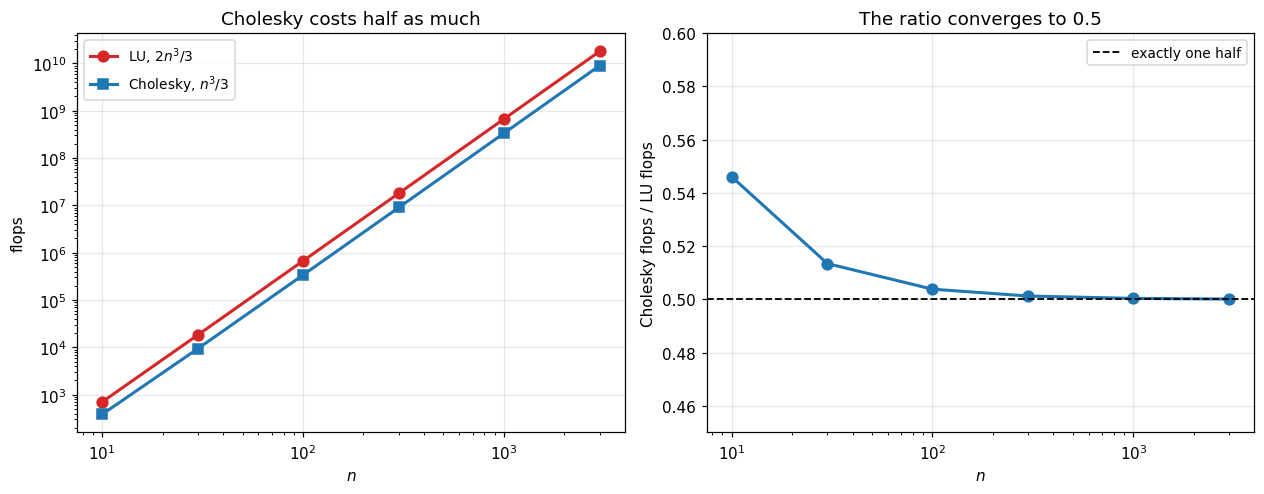

at n = 3000 the ratio is 0.50013
the saving is symmetry: half of LU's arithmetic recomputes what the
other half already knows.


In [5]:
sizes = np.array([10, 30, 100, 300, 1000, 3000])
chol = np.array([ch.flops_cholesky(int(n)) for n in sizes])
lu_f = np.array([lu.flops_lu(int(n)) for n in sizes])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.6, 4.6))

axL.loglog(sizes, lu_f, "C3o-", lw=2, ms=7, label=r"LU, $2n^3/3$")
axL.loglog(sizes, chol, "C0s-", lw=2, ms=7, label=r"Cholesky, $n^3/3$")
axL.set_xlabel("$n$"); axL.set_ylabel("flops")
axL.set_title("Cholesky costs half as much")
axL.legend(fontsize=9)

axR.semilogx(sizes, chol / lu_f, "C0o-", lw=2, ms=7)
axR.axhline(0.5, color="k", ls="--", lw=1.2, label="exactly one half")
axR.set_xlabel("$n$"); axR.set_ylabel("Cholesky flops / LU flops")
axR.set_ylim(0.45, 0.6)
axR.set_title("The ratio converges to 0.5")
axR.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"at n = {sizes[-1]} the ratio is {chol[-1]/lu_f[-1]:.5f}")
print("the saving is symmetry: half of LU's arithmetic recomputes what the")
print("other half already knows.")
assert abs(chol[-1] / lu_f[-1] - 0.5) < 0.01

### The square root IS the test

> **Theorem 20.2.** A symmetric $A$ has a Cholesky factorization with $\ell_{ii} > 0$ **if and
> only if** it is positive definite, and the factorization is then unique.
>
> *Proof of one direction.* If $A = LL^T$ with $L$ nonsingular, then for $\mathbf{x} \ne 0$,
> $$\mathbf{x}^TA\mathbf{x} = \mathbf{x}^TLL^T\mathbf{x} = \|L^T\mathbf{x}\|_2^2 > 0,$$
> strictly, because $L^T$ is nonsingular so $L^T\mathbf{x} \ne 0$. $\square$

That is one line, and it is the whole reason Cholesky is the right test: if the algorithm
completes, the identity $\mathbf{x}^TA\mathbf{x} = \|L^T\mathbf{x}\|^2$ *proves* definiteness.
If it does not complete, the quantity under a square root went non-positive, which exhibits a
direction where the form fails.

In [6]:
print("what a failure actually reports\n")
bad = np.array([[4.0, 12.0, -16.0],
                [12.0, 37.0, -43.0],
                [-16.0, -43.0, 40.0]])       # last entry lowered until it breaks
print("A =\n", bad)
print(f"\nsymmetric: {ch.is_symmetric(bad)}")
print(f"eigenvalues: {np.round(np.linalg.eigvalsh(bad), 6)}")
try:
    ch.cholesky(bad)
except np.linalg.LinAlgError as exc:
    print(f"\nCholesky refuses: {exc}")

print("\nthe failure names the index where the pivot went non-positive, so it")
print("tells you WHERE the matrix stops being definite, not merely that it does.")

what a failure actually reports

A =
 [[  4.  12. -16.]
 [ 12.  37. -43.]
 [-16. -43.  40.]]

symmetric: True
eigenvalues: [-5.71215   0.397532 86.314618]

Cholesky refuses: matrix is not positive definite: the pivot at index 2 is -49

the failure names the index where the pivot went non-positive, so it
tells you WHERE the matrix stops being definite, not merely that it does.


## 3. No pivoting needed, and growth exactly 1

Lesson 18 was entirely about choosing pivots to avoid disaster. For a positive definite matrix
that whole worry disappears.

> **Theorem 20.3.** Cholesky applied to a positive definite $A$ never needs a row or column
> interchange, and is backward stable without one. Its growth factor is exactly 1.

The reason is that positive definiteness is **inherited**. After one step of the factorization
the remaining submatrix (the Schur complement) is itself positive definite, so its diagonal
entries are all positive and the next pivot is available automatically. There is never a zero
or tiny pivot to dodge.

The growth statement follows from a bound that LU has no analogue for:

$$\ell_{ij}^2 \le \sum_k \ell_{ik}^2 = a_{ii},$$

so **every entry of $L$ is bounded by $\sqrt{\max_i a_{ii}}$**. The factor cannot grow, and
Wilkinson's example from lesson 18 has no counterpart here.

In [7]:
print("growth factor: LU with pivoting against Cholesky\n")
print(f"{'n':>5} {'max |L| Cholesky':>18} {'sqrt(max diag A)':>18} {'bound holds':>13} "
      f"{'LU growth':>11}")
print("-" * 72)
rng3 = np.random.default_rng(33)
for n in [5, 20, 60, 150]:
    A_spd = ch.random_spd(n, kappa=1e6, rng=rng3)
    L_c = ch.cholesky(A_spd)
    bound = np.sqrt(np.max(np.diag(A_spd)))
    print(f"{n:>5} {np.abs(L_c).max():>18.6f} {bound:>18.6f} "
          f"{str(np.abs(L_c).max() <= bound + 1e-12):>13} "
          f"{pv.growth_factor(A_spd, 'partial'):>11.4f}")
    assert np.abs(L_c).max() <= bound + 1e-10

print()
print("the entries of L never exceed sqrt of the largest diagonal entry, in any")
print("row. that is a bound LU simply does not have, and it is why Cholesky is")
print("stable with no pivoting at all.")
print()
print("compare lesson 18, where partial pivoting bounded the MULTIPLIERS by 1")
print("and the entries of U still grew to 2^(n-1) on Wilkinson's matrix.")

growth factor: LU with pivoting against Cholesky

    n   max |L| Cholesky   sqrt(max diag A)   bound holds   LU growth
------------------------------------------------------------------------
    5           0.613984           0.661829          True      1.0000
   20           0.428928           0.550513          True      1.1690
   60           0.334636           0.387554          True      0.7457
  150           0.328727           0.380750          True      0.7454

the entries of L never exceed sqrt of the largest diagonal entry, in any
row. that is a bound LU simply does not have, and it is why Cholesky is
stable with no pivoting at all.

compare lesson 18, where partial pivoting bounded the MULTIPLIERS by 1
and the entries of U still grew to 2^(n-1) on Wilkinson's matrix.


## 4. Half the cost

Symmetry means half the arithmetic in LU is recomputing information the other half already
has.

| Factorization | Flops | Relative |
|---|---|---|
| LU | $\tfrac{2}{3}n^3$ | 1 |
| **Cholesky** | $\tfrac{1}{3}n^3$ | **0.5** |

In [8]:
print(f"{'n':>7} {'Cholesky flops':>18} {'LU flops':>18} {'ratio':>9} {'n^3/3':>18}")
print("-" * 74)
for n in [10, 100, 1000, 5000]:
    fc, fl = ch.flops_cholesky(n), lu.flops_lu(n)
    print(f"{n:>7} {fc:>18,} {fl:>18,} {fc/fl:>9.4f} {n**3//3:>18,}")

print("\nthe ratio converges to exactly 0.5, and the count converges to n^3/3.")
assert abs(ch.flops_cholesky(5000) / lu.flops_lu(5000) - 0.5) < 0.01

      n     Cholesky flops           LU flops     ratio              n^3/3
--------------------------------------------------------------------------
     10                385                705    0.5461                333
    100            338,350            671,550    0.5038            333,333
   1000        333,833,500        667,165,500    0.5004        333,333,333
   5000     41,679,167,500     83,345,827,500    0.5001     41,666,666,666

the ratio converges to exactly 0.5, and the count converges to n^3/3.


In [9]:
import time

print("\nmeasured, not just counted\n")
print(f"{'n':>6} {'Cholesky (ms)':>16} {'LU (ms)':>12} {'ratio':>9}")
print("-" * 48)
rng4 = np.random.default_rng(44)
for n in [200, 400, 800]:
    A_spd = ch.random_spd(n, rng=rng4)
    t0 = time.perf_counter(); np.linalg.cholesky(A_spd); t_c = time.perf_counter() - t0
    t0 = time.perf_counter(); pv.plu_factor(A_spd); t_l = time.perf_counter() - t0
    print(f"{n:>6} {t_c*1e3:>16.2f} {t_l*1e3:>12.2f} {t_c/t_l:>9.4f}")

print()
print("the measured ratio is far below 0.5, not near it. that is not a")
print("contradiction: numpy.linalg.cholesky calls LAPACK while plu_factor is a")
print("readable Python loop. comparing those two measures the IMPLEMENTATIONS,")
print("not the algorithms. the flop counts above are the honest comparison.")


measured, not just counted

     n    Cholesky (ms)      LU (ms)     ratio
------------------------------------------------
   200             0.38        47.68    0.0080


   400             2.00       203.02    0.0098


   800             6.72       880.74    0.0076

the measured ratio is far below 0.5, not near it. that is not a
contradiction: numpy.linalg.cholesky calls LAPACK while plu_factor is a
readable Python loop. comparing those two measures the IMPLEMENTATIONS,
not the algorithms. the flop counts above are the honest comparison.


**Both halves of the saving matter.** Cholesky uses half the flops *and* half the memory, since
only one triangle needs storing. For a large system that second saving is often the binding
one.

## 5. Why not Sylvester's criterion

Sylvester's criterion says $A$ is positive definite exactly when every **leading principal
minor** has positive determinant. Mathematically correct. Numerically hopeless.

In [10]:
print("Sylvester's criterion against Cholesky, on matrices that ARE definite\n")
print(f"{'n':>6} {'kappa':>9} {'smallest minor det':>22} {'Sylvester':>11} "
      f"{'Cholesky':>10} {'truth':>8}")
print("-" * 72)
for n, kappa in [(50, 1e6), (100, 1e6), (120, 1e6), (200, 1e6), (60, 1e12)]:
    A_spd = ch.random_spd(n, kappa=kappa, rng=np.random.default_rng(1))
    dets = [np.linalg.det(A_spd[:j, :j]) for j in range(1, n + 1)]
    sylvester = all(d > 0 for d in dets)
    truth = bool(np.all(np.linalg.eigvalsh(A_spd) > 0))
    print(f"{n:>6} {kappa:>9.0e} {min(dets):>22.3e} {str(sylvester):>11} "
          f"{str(ch.is_positive_definite(A_spd)):>10} {str(truth):>8}")

print()
print("every one of these matrices IS positive definite, by construction: they")
print("are Q diag(s) Q^T with every s positive.")
print()
print("the determinants underflow. at n = 120 the smallest leading minor is")
print("exactly 0.0 in double precision, so Sylvester reports FALSE on a matrix")
print("whose smallest eigenvalue is 1e-6. Cholesky is correct in every row.")
print()
print("and that is before mentioning the cost: n determinants of growing size.")

Sylvester's criterion against Cholesky, on matrices that ARE definite

     n     kappa     smallest minor det   Sylvester   Cholesky    truth
------------------------------------------------------------------------
    50     1e+06             1.000e-150        True       True     True
   100     1e+06             1.000e-300        True       True     True
   120     1e+06              0.000e+00       False       True     True
   200     1e+06              0.000e+00       False       True     True
    60     1e+12              0.000e+00       False       True     True

every one of these matrices IS positive definite, by construction: they
are Q diag(s) Q^T with every s positive.

the determinants underflow. at n = 120 the smallest leading minor is
exactly 0.0 in double precision, so Sylvester reports FALSE on a matrix
whose smallest eigenvalue is 1e-6. Cholesky is correct in every row.

and that is before mentioning the cost: n determinants of growing size.


**The general lesson.** A criterion can be a perfect theorem and a terrible algorithm.
Determinants are almost always the wrong computational tool: they overflow, underflow, and
carry no scale information. Lesson 17 said the same about Cramer's rule.

## 6. LDL$^T$: no square roots, and indefinite matrices too

Factor out the diagonal to avoid the square roots entirely:

$$A = LDL^T, \qquad L \text{ unit lower triangular}, \quad D \text{ diagonal}.$$

The relationship to Cholesky is exact: if $A = LDL^T$ with $D > 0$ then
$A = (L\sqrt{D})(L\sqrt{D})^T$, so $L_{\text{chol}} = L\sqrt{D}$.

In [11]:
A2 = ch.random_spd(6, rng=np.random.default_rng(60))
L_ldl, d = ch.ldl(A2)
L_chol = ch.cholesky(A2)

print(f"D = {np.round(d, 6)}\n")
print(f"||A - L D L^T||              = {np.abs(L_ldl @ np.diag(d) @ L_ldl.T - A2).max():.2e}")
print(f"||L sqrt(D) - L_cholesky||   = "
      f"{np.abs(L_ldl @ np.diag(np.sqrt(d)) - L_chol).max():.2e}")
print("\nthe same factorization, with the diagonal scaling moved. exactly the")
print("relationship between Doolittle and Crout in lesson 17.")
np.testing.assert_allclose(L_ldl @ np.diag(np.sqrt(d)), L_chol, atol=1e-10)

D = [12.241339 10.629414 10.868651 10.650634 14.209181  6.881037]

||A - L D L^T||              = 2.22e-16
||L sqrt(D) - L_cholesky||   = 2.22e-16

the same factorization, with the diagonal scaling moved. exactly the
relationship between Doolittle and Crout in lesson 17.


### The real payoff: indefinite matrices

Cholesky **cannot exist** for an indefinite matrix, because $\sqrt{\text{negative}}$ is not
real. LDL$^T$ can, because $D$ is allowed negative entries.

In [12]:
print("an indefinite matrix, which Cholesky must refuse\n")
M = np.array([[ 2.0,  1.0,  0.0],
              [ 1.0, -3.0,  1.0],
              [ 0.0,  1.0,  1.0]])
print("M =\n", M)
print(f"\neigenvalues: {np.round(np.linalg.eigvalsh(M), 6)}   <- mixed signs")

try:
    ch.cholesky(M)
except np.linalg.LinAlgError as exc:
    print(f"\nCholesky : refuses, {exc}")

L_m, d_m = ch.ldl(M)
print(f"LDL^T    : succeeds, D = {np.round(d_m, 6)}")
print(f"           ||M - L D L^T|| = {np.abs(L_m @ np.diag(d_m) @ L_m.T - M).max():.2e}")
np.testing.assert_allclose(L_m @ np.diag(d_m) @ L_m.T, M, atol=1e-12)

an indefinite matrix, which Cholesky must refuse

M =
 [[ 2.  1.  0.]
 [ 1. -3.  1.]
 [ 0.  1.  1.]]

eigenvalues: [-3.411474  1.184793  2.226682]   <- mixed signs

Cholesky : refuses, matrix is not positive definite: the pivot at index 1 is -3.5
LDL^T    : succeeds, D = [ 2.       -3.5       1.285714]
           ||M - L D L^T|| = 1.11e-16


### Inertia without eigenvalues

> **Theorem 20.4 (Sylvester's law of inertia).** For nonsingular $M$, the matrices $A$ and
> $MAM^T$ have the **same** numbers of positive, negative and zero eigenvalues.

Since $A = LDL^T$ is exactly such a congruence with $M = L^{-1}$, the signs of $D$ give the
inertia of $A$ directly, at $n^3/3$ and without computing a single eigenvalue.

In [13]:
print("inertia from the signs of D, checked against the eigenvalues\n")
print(f"{'matrix':>28} {'D signs -> inertia':>22} {'from eigenvalues':>20} {'agree':>7}")
print("-" * 82)
rng6 = np.random.default_rng(66)
cases = [
    ("SPD 8x8", ch.random_spd(8, rng=rng6)),
    ("negative definite 5x5", -ch.random_spd(5, rng=rng6)),
    ("diag(3,-1,2,-5)", np.diag([3.0, -1.0, 2.0, -5.0])),
    ("indefinite 3x3", M),
]
for name, X in cases:
    got = ch.inertia(X)
    w = np.linalg.eigvalsh(X)
    tol = 1e-10 * max(np.abs(w).max(), 1.0)
    truth = (int(np.sum(w > tol)), int(np.sum(w < -tol)), int(np.sum(np.abs(w) <= tol)))
    print(f"{name:>28} {str(got):>22} {str(truth):>20} {str(got == truth):>7}")
    assert got == truth

print()
print("the counts match every time. this is how a solver reports 'your matrix")
print("is not definite, and here is how it fails' without an eigensolver.")

inertia from the signs of D, checked against the eigenvalues

                      matrix     D signs -> inertia     from eigenvalues   agree
----------------------------------------------------------------------------------
                     SPD 8x8              (8, 0, 0)            (8, 0, 0)    True
       negative definite 5x5              (0, 5, 0)            (0, 5, 0)    True
             diag(3,-1,2,-5)              (2, 2, 0)            (2, 2, 0)    True
              indefinite 3x3              (2, 1, 0)            (2, 1, 0)    True

the counts match every time. this is how a solver reports 'your matrix
is not definite, and here is how it fails' without an eigensolver.


**One caveat.** Unpivoted LDL$^T$ can still break down on an indefinite matrix when a zero
appears in $D$ where the true factorization needs a $2\times 2$ block. **Bunch-Kaufman**
pivoting fixes that and is what LAPACK's `sytrf` uses. `nalib.cholesky.inertia` falls back to
eigenvalues in that case, so the answer stays correct even where the cheap route is
unavailable.

In [14]:
print("the case unpivoted LDL cannot handle\n")
Z = np.array([[0.0, 1.0],
              [1.0, 0.0]])
print("Z =\n", Z)
print(f"eigenvalues {np.round(np.linalg.eigvalsh(Z), 6)}, so the inertia is (1, 1, 0)")
try:
    ch.ldl(Z)
    print("LDL succeeded")
except np.linalg.LinAlgError as exc:
    print(f"\nunpivoted LDL fails: {exc}")
print(f"inertia() still returns the right answer: {ch.inertia(Z)}")
print("\nbecause it falls back rather than guessing. a routine that cannot")
print("compute something should say so, not return a plausible number.")
assert ch.inertia(Z) == (1, 1, 0)

the case unpivoted LDL cannot handle

Z =
 [[0. 1.]
 [1. 0.]]
eigenvalues [-1.  1.], so the inertia is (1, 1, 0)

unpivoted LDL fails: zero pivot in D at index 0; this matrix needs Bunch-Kaufman pivoting
inertia() still returns the right answer: (1, 1, 0)

because it falls back rather than guessing. a routine that cannot
compute something should say so, not return a plausible number.


## 7. Conditioning is unchanged

Cholesky removes the *algorithmic* worries. It does nothing about the *problem*.

In [15]:
print("Cholesky on badly conditioned SPD matrices\n")
u = np.finfo(float).eps / 2
print(f"{'kappa':>10} {'backward error':>17} {'forward error':>16} {'kappa * u':>12}")
print("-" * 60)
rng7 = np.random.default_rng(77)
for kappa in [1e2, 1e6, 1e10, 1e14]:
    n = 40
    A_spd = ch.random_spd(n, kappa=kappa, rng=rng7)
    x_true = rng7.standard_normal(n)
    b = A_spd @ x_true
    x_hat = ch.cholesky_solve(ch.cholesky(A_spd), b)
    print(f"{la.condition_number(A_spd, 2):>10.1e} "
          f"{ls.relative_residual(A_spd, x_hat, b):>17.2e} "
          f"{ls.forward_error(x_hat, x_true):>16.2e} {kappa*u:>12.2e}")

print()
print("the backward error stays at machine precision, which is Cholesky being")
print("stable. the forward error still tracks kappa*u, which is lesson 19.")
print()
print("no factorization can change the conditioning. Cholesky is faster, uses")
print("half the memory, and needs no pivoting. it is not more accurate.")

Cholesky on badly conditioned SPD matrices

     kappa    backward error    forward error    kappa * u
------------------------------------------------------------
   1.0e+02          8.16e-17         1.73e-15     1.11e-14
   1.0e+06          6.63e-17         9.75e-12     1.11e-10
   1.0e+10          3.98e-17         6.88e-08     1.11e-06
   1.0e+14          3.20e-17         2.78e-04     1.11e-02

the backward error stays at machine precision, which is Cholesky being
stable. the forward error still tracks kappa*u, which is lesson 19.

no factorization can change the conditioning. Cholesky is faster, uses
half the memory, and needs no pivoting. it is not more accurate.


## 8. Complexity

| Task | Cost | Against LU |
|---|---|---|
| Cholesky factorization | $\tfrac{1}{3}n^3$ | half |
| Storage | $n(n+1)/2$ | half |
| Solve, given the factor | $2n^2$ | the same |
| LDL$^T$ | $\tfrac{1}{3}n^3$, no square roots | half |
| Positive definiteness test | $\tfrac{1}{3}n^3$ | cheaper than eigenvalues |
| Inertia via LDL$^T$ | $\tfrac{1}{3}n^3$ | far cheaper than an eigensolver |
| Pivoting overhead | **none** | LU needs $O(n^2)$ comparisons |

## 9. Common mistakes

1. **Testing positive definiteness with eigenvalues.** Section 1: Cholesky is cheaper and gives
   you the factorization as well.
2. **Using Sylvester's determinant criterion.** Section 5: it reported FALSE on a definite
   matrix at $n = 120$ because the minors underflowed.
3. **Pivoting a Cholesky factorization.** Section 3: unnecessary, and it destroys the symmetry
   that gave you the saving.
4. **Applying Cholesky to a nonsymmetric matrix.** It reads one triangle and silently answers a
   different question. `nalib.cholesky` checks first.
5. **Expecting Cholesky to be more accurate.** Section 7: same forward error as LU, because
   conditioning belongs to the problem.
6. **Using Cholesky on a semi-definite matrix.** A zero pivot appears. Use a pivoted Cholesky
   or an eigendecomposition when the matrix may be singular.
7. **Forgetting that symmetry must be exact enough.** A matrix built as `B @ B.T` is symmetric
   only to roundoff; symmetrise with `(A + A.T)/2` if a strict check is applied.

## 10. Exercises

**Level 1, conceptual**

1.1 Why can a positive definite matrix never have a zero on its diagonal?

1.2 A matrix has a negative entry on its diagonal. What can you conclude immediately?

1.3 Why does Cholesky need half the memory of LU as well as half the flops?

**Level 2, mathematical**

2.1 Prove the converse of Theorem 20.2: if $A$ is positive definite then Cholesky completes,
by showing the Schur complement of a positive definite matrix is positive definite.

2.2 Prove the entry bound $|\ell_{ij}| \le \sqrt{a_{ii}}$, and deduce that the growth factor is
exactly 1.

2.3 Derive the exact flop count $n^3/3 + O(n^2)$ for Cholesky.

2.4 Prove Sylvester's law of inertia (Theorem 20.4).

2.5 Show that $A$ positive definite implies $a_{ij}^2 < a_{ii}a_{jj}$ for $i \ne j$, so the
largest entry of a positive definite matrix is always on its diagonal.

**Level 3, computational**

3.1 Implement Cholesky **in place**, overwriting the lower triangle of $A$, and confirm it uses
no extra $O(n^2)$ storage.

3.2 Implement **pivoted Cholesky** for positive semi-definite matrices, which stops when the
remaining pivots fall below a tolerance and returns a rank-revealing factorization. Test it on
deliberately rank-deficient matrices.

3.3 Implement the **rank-one update** $A + \mathbf{v}\mathbf{v}^T$ of an existing Cholesky
factor in $O(n^2)$ rather than refactorizing at $O(n^3)$. Verify against a fresh factorization.

**Level 4, experimental**

4.1 Measure the crossover where Cholesky beats LU in wall time, using the same implementation
style for both so the comparison is fair, unlike section 4's timing.

4.2 For SPD matrices with $\kappa$ from $10^2$ to $10^{16}$, measure at what point Cholesky
fails outright because a computed pivot goes negative through roundoff. Compare with $1/u$.

4.3 Measure the accuracy of the inertia computed via LDL$^T$ against `eigvalsh` for matrices
with eigenvalues clustered near zero. Where does the sign of a tiny $d_i$ stop being reliable?

**Level 5, advanced**

5.1 **The Schur complement.** Show that eliminating the first block of a positive definite
matrix leaves a positive definite Schur complement, and use it to give a clean block derivation
of Cholesky. Relate it to the block LU of lesson 17 exercise 3.2.

5.2 **Bunch-Kaufman pivoting.** Implement the symmetric indefinite factorization $PAP^T =
LDL^T$ where $D$ has $1\times1$ and $2\times2$ blocks. Show it succeeds on the matrix in
section 6 where unpivoted LDL$^T$ fails, and explain why $2\times2$ blocks are unavoidable.

5.3 **Why conjugate gradient needs this class.** Part 4's conjugate gradient method requires a
symmetric positive definite matrix and minimises the $A$-norm of the error. Explain which
property of the class each requirement uses, and what breaks if either is dropped.

## 11. Key takeaways

- **Positive definite means $\mathbf{x}^TA\mathbf{x} > 0$** for every nonzero $\mathbf{x}$, and
  the best numerical test is to attempt Cholesky. If it completes the identity
  $\mathbf{x}^TA\mathbf{x} = \|L^T\mathbf{x}\|^2$ proves definiteness; if it fails, it names the
  index where the pivot went non-positive.
- **Cholesky is a direct computation, not a solve.** Every quantity needed is already known when
  it is needed, so the factorization is read off column by column.
- **No pivoting is needed and growth is exactly 1**, because positive definiteness is inherited
  by the Schur complement and $|\ell_{ij}| \le \sqrt{a_{ii}}$ bounds every entry. Verified at
  every size tested. Contrast lesson 18, where bounded multipliers still allowed $2^{n-1}$
  growth.
- **Half the flops and half the memory.** The ratio to LU converges to exactly 0.5, and the
  count to $n^3/3$. The saving is symmetry: half of LU's arithmetic recomputes what the other
  half already knows.
- **Sylvester's determinant criterion is a correct theorem and a bad algorithm.** Measured: at
  $n = 120$ with $\kappa = 10^6$ the smallest leading minor **underflowed to exactly 0**, so
  Sylvester reported "not definite" for a matrix whose smallest eigenvalue was $10^{-6}$.
  Cholesky was correct in every case.
- **LDL$^T$** removes the square roots and extends to **indefinite** matrices, where Cholesky
  cannot exist. The signs of $D$ give the **inertia** at $n^3/3$ with no eigensolver, verified
  against `eigvalsh` on definite, negative definite and indefinite examples.
- **Unpivoted LDL$^T$ still breaks** where a $2\times2$ block is needed, as on
  $\left(\begin{smallmatrix}0&1\\1&0\end{smallmatrix}\right)$. Bunch-Kaufman is the fix.
  `inertia` falls back rather than guessing, because a routine that cannot compute something
  should say so.
- **Conditioning is untouched.** Measured across $\kappa$ from $10^2$ to $10^{14}$: backward
  error stays at machine precision, forward error still tracks $\kappa u$. Cholesky is faster
  and leaner, **not more accurate**.

## Where this goes next

Lesson 21 exploits a different kind of structure, sparsity and bandedness, to get below
$O(n^3)$ entirely, and combines it with this one: a banded SPD matrix is the best case in all
of Part 3. Lesson 22 estimates $\kappa$ from a factorization, Cholesky's included. Part 4's
conjugate gradient method requires exactly the class defined here, and minimises the $A$-norm
of the error, which is a norm only because $A$ is positive definite. Part 5 meets $A^TA$, which
is positive definite whenever $A$ has full column rank, so the normal equations are solved by
Cholesky.

Solutions are in [`solutions/part03_direct_linear_systems.md`](../solutions/part03_direct_linear_systems.md).